In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("cs1090a_hw1.ipynb")

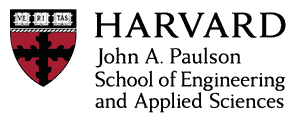

# CS1090A Introduction to Data Science
## Homework 1: A Reproducible Scraping & EDA Pipeline

**Harvard University**<br/>
**Fall 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, and Chris Gumb

<hr style="height:2.4pt">

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import json
import time
import glob
import datetime
from concurrent.futures import ThreadPoolExecutor
from IPython import display

In [ ]:
# For calculating total notebook runtime
notebook_start = time.time()

In [ ]:
style = '''<style>
h2, h3, h4 {
    background-color: #7efcf5;
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    padding: 0em;
    color: #1F2937;
}
h3 {
    background-color: #7efcf5;
    border-top: 5px solid #7ec4fc;
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    padding: 0.5em;
}
div.md {
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    border-bottom: 5px solid #7ec4fc;
    padding: 0.5em;
}
div.prompt {
    background: #d1ffbd;
    border: thin solid black;
    border-radius: 2px;
    padding: 5px;
    margin: 0.5em 0;
    color: #1F2937;
}
/* A colour on the box does not reach <code> or <a> inside it. JupyterLab's dark
   theme gives inline code background-color: var(--jp-layout-color2) (#424242) and
   colours links #64b5f6, so setting only the box colour would put dark text on a
   dark code background. Code and links outside a box are left alone, where the
   theme's own pairing is already right. */
div.prompt code, div.alert code {
    background: rgba(0, 0, 0, 0.06);
    color: #1F2937;
}
div.prompt a, div.alert a {
    color: #1D4ED8;
}
</style>'''
display.display(display.HTML(style))

## Assignment Overview

You'll build a **reproducible data pipeline** around
[screenboston.com](https://screenboston.com), a site that aggregates movie
screenings from theaters around Boston. You will collect the data (live page +
historical snapshots), structure it with Pandas, enrich it from Wikipedia, use
EDA and visualization to understand it — and finish by making a **data-driven
recommendation** to the theaters themselves.

Think of the assignment is a structured mini-project. Each question tells
you the **goal**, the **required artifact** (file, variable, or figure), and any
**constraints** — how you get there is up to you. Sections 1–2 and the
supplemental notebooks (*MediaWiki API*, *Matplotlib & Seaborn reference*)
demonstrate every technique you'll need.

**The reproducibility theme.** A grader (or future you) should be able to re-run
your notebook and get the *same dataset and results*. Concretely, throughout
this assignment:

- **Guard every fetch** — code that touches the network must first check for a
  cached copy on disk and skip the request if it exists.
- **Derive results from pinned data** — that is, historical Wayback snapshots and cached
  files, not whatever the live web happens to say today.
- You will **submit your small data files** alongside the notebook (see
  Question 10), so your results are reproducible without the network.

**Structure** (10 questions + wrap-up; CS1090A graded out of 95, AC209A out of
100 — see the AC209A section):

1. Acquire the live page (4 pts)
2. Parse HTML into records (10 pts)
3. A reproducible dataset from Wayback snapshots (12 pts)
4. Build and clean a DataFrame (12 pts)
5. Exploratory data analysis (14 pts)
6. Resolve films to Wikipedia page IDs (8 pts)
7. Cache Wikipedia page content to disk (4 pts)
8. Enrich the data and ask a new question (10 pts)
9. **The decision: program Halloween weekend (14 pts)**
10. Reproducibility reflection & data submission (6 pts)
11. Wrap-up (1 pt)
12. **AC209A only:** SQL + concurrency (5 pts — required for AC209A; CS1090A
    students may skip this section entirely)

## Instructions

<div class="prompt" style="background: lightgreen; border: thin solid black; border-radius: 2px; padding: 5px; color: #1F2937;">

**General**
- To submit your notebook and data files, follow the instructions on the Canvas assignment page.
- **CS1090A is graded out of 95; AC209A is graded out of 100.** Three subquestions are marked *AC209A only*: 6a and 7a (concurrency evidence, 1 point each) and 8a (SQL, 3 points). CS1090A students skip those three and lose nothing by doing so — they are required work for AC209A, not extra credit for anyone.
- Plots must be legible and interpretable *without reading the code that generated them*: axis labels, a descriptive title, and a legend where appropriate.
- When asked to interpret a result, explain what it *means* — not what the plot looks like.
- The automated tests are **smoke tests only**: they check that required artifacts exist and have the right shape. Passing them is necessary, not sufficient — most credit is assigned by rubric to your approach, analysis, and writing.
- Your code must be **re-runnable — including offline**: "Restart Kernel and Run All Cells" must complete without error, and given your submitted data files it must complete *without any network access* (this is how it will be graded). 
- Only make network requests when the corresponding cache is empty. Gratuitous re-fetching (of pages you already saved) will lose credit.
- Feel free to add code or markdown cells. Include a written response wherever a question asks for one.
- **Before submitting: Restart Kernel and Run All Cells**, confirm no errors and that all output is visible.

**Use of AI tools**

AI tools — coding agents especially — are part of the modern data science workflow. One principle governs everything: **you are accountable for whatever you submit.** You must understand it, be able to communicate it, and be able to justify it.

- Written interpretations, the Question 9 memo, and the Question 10 reflection must be **your own reasoning in your own words**.
- In Question 10 you will briefly **disclose** how you used AI on this assignment and what you did to verify its output.
- Remember, any understanding you skip here will be paid for later in quizzes & midterms.
</div>

## Question 1: Acquire the live page

<p>Get the current HTML of <a href="https://screenboston.com">screenboston.com</a> and cache it to disk.</p>

<p><b>Why HTML at all?</b> Before scraping any site, look for structured data first — an official API, or the JSON many modern sites load their pages from. screenboston has one: <code>screenboston.com/__data.json</code> serves the current schedule as JSON, and parsing it would be easier than parsing HTML. We parse HTML anyway for one decisive reason: this assignment's dataset is <i>historical</i>, and the past only exists in the Wayback Machine's snapshots of the <i>rendered page</i>.</p>

<div class=prompt>

**Artifact:** the file <code>data/html/screenboston.html</code>.

**Constraints:**
- The fetch must be <b>guarded</b>: make an HTTP request only if the file does not already exist.
- <b>Identify yourself</b>: send a descriptive <code>User-Agent</code> naming the course. Some sites block anonymous default clients.
</div>

<p><b>Note what you just built:</b> this file is the one piece of your dataset that is <i>not</i> reproducible — it captures whatever the site showed on the day you ran this cell. (We'll fix that in Question 3)</p>

In [ ]:
# your code here
...

In [ ]:
grader.check("q1")

## Question 2: Parse the HTML into records

<p>Turn the page into structured data: one record per screening (a film, at a theater, on a date).</p>

<div class=prompt>

**Artifact:** a list of dictionaries named <code>movies</code>, one per screening, each with <i>exactly</i> these keys:

```python
{'title': 'Monty Python and the Holy Grail',
 'directors': 'Terry Jones, Terry Gilliam',   # plural key, even for one director
 'year': 1975,                                 # int
 'genre': 'Adventure',
 'runtime': '1h 31m',
 'theater': 'Coolidge Corner Theatre',
 'screen_date': '2026-07-11',
 'screen_times': '11:59 PM'}
```

**Constraints:**
- Write your parsing as <b>reusable function(s)</b> that take an HTML string — Question 3 will run them on ~20 more pages.
- Report how many records you extracted and display one example.
- Some listings are missing fields; a record with a <code>None</code> value is fine, but don't let one malformed listing crash the whole parse.
- <b>Never fail silently.</b> Your parser must also report how many listings it <i>failed</i> to parse. A page whose structure has drifted enough to break the parser should announce itself ("parsed 0 of 66 listings") — silent errors cause issues downstream and are a nightmare to debug.
</div>

**Hints:** your browser's *inspect* tool is how you learn the page's structure. Screening dates are not inside each listing — look at what *contains* the listings.

In [ ]:
# your code here
...

In [ ]:
grader.check("q2")

## Question 3: A reproducible dataset from Wayback snapshots

<p>The live page only shows the next couple of weeks. The Internet Archive's
<a href="https://archive.org/help/wayback_api.php">Wayback Machine availability API</a> lets you retrieve historical snapshots of the page — and because snapshots are <b>pinned</b>, a dataset built from them is reproducible.</p>

<div class=prompt>

**Artifacts:**
1. Snapshot HTML files saved as <code>data/html/snapshot_YYYYMMDD.html</code> — covering <b>all available snapshots</b> of screenboston.com <b>through September 8, 2026</b>.
2. <code>data/movies.json</code> — the combined list of screening records parsed from <i>every</i> HTML file in <code>data/html/</code> (snapshots + live page), written with the <code>json</code> module.

**Constraints:**
- Both steps must be <b>guarded</b> (i.e., check for existing cache before running) — and guard <b>per file</b>, so an interrupted run resumes instead of restarting (or worse, permanently locking in a partial download).
- <b>The archive spans a site redesign.</b> These snapshots run over two years, and
screenboston.com did not look the same throughout. At least one early snapshot will not
parse with selectors written for today's page. Your parser must <b>say so</b> rather than
quietly return an empty list — that is what "never fail silently" in Q2 was for.
<i>Extracting that page's listings anyway is optional and worth a bonus point</i>; be
warned that the older layout carries no release year at all, so <code>year</code> would
have to be <code>None</code> for those records.
- <b>Expect throttling and handle it.</b> The whole class hits archive.org the same week; you *will* see slow responses or HTTP 429. Check status codes before parsing or saving anything — a cached error page is worse than no cache (since a simple guard can't tell them apart). Sanity-check each saved snapshot (does it parse to a plausible number of listings?).
- Assume any well-formed page covers at least through the end of its snapshot month, and that a day's schedule doesn't change once displayed.
- Don't worry about duplicate screenings across overlapping snapshots — Question 4 deals with them.
- Report which snapshots you found and the total number of records.
</div>

**Hint:** the availability API returns the snapshot *closest* to a timestamp — probing one timestamp per month is a reasonable way to sweep the archive's history. Store your list in `movies` (it should now include records from all pages).

In [ ]:
# your code here
...

In [ ]:
# your code here
...

In [ ]:
# Display info about snapshots and parse results
print("Snapshots on disk:")
print(sorted(os.path.basename(f) for f in glob.glob('data/html/snapshot_*')))
print(f"{len(movies)} total screening records across all HTML files.")

In [ ]:
grader.check("q3")

## Question 4: Build and clean a DataFrame

<div class=prompt>

**Artifact:** a DataFrame <code>df</code> built from <code>data/movies.json</code>, satisfying:

1. **No duplicate rows** (rows where *all* values match — overlapping snapshots create many). Report how many rows you dropped and how many remain.
2. A **missingness audit**: NaN counts per column, and a display of the rows containing at least one NaN (or confirmation there are none).
3. **A dtype on each column that matches what the column holds**: <code>screen_date</code> as a datetime type, <code>runtime</code> as a timedelta type.
4. Sorted by ascending <code>screen_date</code>.

<b>Verify as you go</b> — after each transform, check what you actually produced (<code>.shape</code>, <code>.dtypes</code>, a spot-check of rows). Whether you or an 'assistant' wrote the code, the sign-off on the result is your responsibility.

Then use the clean frame to create:

5. A table of **screenings per theater per calendar month** (rows = month, columns = theater; restrict columns to the 6 busiest theaters). Then, in one or two sentences: what do you notice?
</div>

In [ ]:
# your code here
...

In [ ]:
# your code here
...

*your answer here*

In [ ]:
grader.check("q4")

## Question 5: Exploratory data analysis

Every visualization needs: labeled axes, descriptive title, and a written interpretation of what it *means*.
These are relatively simple visualizations. You should really try writing them yourself.

(Note: "Screening" refers to one row of the `df`.)

### 5.1 Longest films

Display the 10 longest reported runtimes (rows, descending).

Then, in one or two sentences: what are these longest entries, and what does that tell you about what the `runtime` column is measuring?

In [ ]:
# your code here
...

*your answer here*

### 5.2 Screening counts

Side-by-side subplots with a shared y-axis: screenings by theater, and screenings by genre.

In [ ]:
# your code here
...

*your answer here*

### 5.3 Film vintage

A pair of plots showing the distribution of release `year`, overall and broken out by theater (your choice of plot types, but justify the choice).

In [ ]:
# your code here
...

*your answer here*

### 5.4 One custom question

Pose a question of your own about the screening data and answer it with an appropriate plot whose *type differs* from those you used above. State the question, your approach, the plot, and your interpretation.

In [ ]:
# your code here
...

*your answer here*

### 5.5 Critique a chart

The provided cell below draws a chart from *your* data, exactly as an over-eager assistant might. It runs without error and looks polished. In a short written answer: what claim does it make, in what specific ways is it misleading, and how would you redraw it so that the visual comparison matches the numbers? (This is the skill the whole module turns on: the tools can draw anything; *you* sign off on what a chart says.)

In [ ]:
# --- 5. PROVIDED CELL: do not edit. Critique the chart this draws. ----------
_rt = df.dropna(subset=["runtime"]).copy()
_rt["runtime_min"] = _rt["runtime"].dt.total_seconds() / 60
_top2 = _rt["theater"].value_counts().head(2).index
_means = _rt[_rt["theater"].isin(_top2)].groupby("theater")["runtime_min"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
_means.plot(kind="bar", ax=ax, color=["C3", "C7"], rot=0)
ax.set_ylim(_means.min() - 2, _means.max() + 1)   # <- look closely
ax.set_ylabel("Avg runtime (min)")
ax.set_title(f"{_means.idxmax()} shows FAR longer films!")
plt.show()
print("Means:", _means.round(1).to_dict())

*your answer here*

## Question 6: Resolve films to Wikipedia page IDs

<p>To enrich our data we need a <b>stable identifier</b> for each film's Wikipedia article. Query the <a href="https://www.mediawiki.org/wiki/API:Main_page">MediaWiki API</a> directly with <code>requests</code> — the numeric <code>pageid</code> is permanent even when article titles change. The <i>MediaWiki API</i> supplemental notebook walks through everything you need.</p>

<div class=prompt>

**Artifact:** a <code>wiki_id</code> column on <code>df</code> (the film's numeric pageid, or <code>NaN</code> when you can't resolve one confidently).

**Constraints:**
- Query each <b>unique film</b> once — not once per screening row.
- Cache your resolved IDs to disk (e.g. a CSV) so re-runs make <b>zero</b> lookup requests.
- Be polite: identify yourself with a User-Agent and handle rate-limiting (HTTP 429 / <code>maxlag</code>) gracefully. Sustained one-search-per-film traffic <i>will</i> get you throttled — plan your request budget.
- Report your coverage (share of screenings with a resolved ID) and show a few films you failed to match — what, if anything, do the misses have in common?

**AC209A (required; CS1090A optional):** parallelize whatever per-film requests remain with a small thread pool (max ~4 workers).
</div>

**Hint (request budget):** film articles follow strong title conventions — <i>"Title (YEAR film)"</i>, <i>"Title (film)"</i>, or just <i>"Title"</i>. The API's <code>action=query&titles=a|b|c</code> form checks up to <b>50 exact titles per request</b> (add <code>redirects=1</code>), which resolves most films in a handful of requests; full-text <code>search</code> is then only needed as a fallback for the stragglers. See the MediaWiki supplemental notebook.

In [ ]:
# your code here
...

In [ ]:
# your code here
...

*your answer here*

In [ ]:
grader.check("q6")

### 6a. Concurrency evidence — AC209A only (1 pt)

Question 6 required you to parallelise the per-film requests with a small thread pool. Point to where you did that, and show evidence it worked: either a timing comparison, or the batch and worker structure together with a measured runtime. One code or markdown cell is enough. Section 1's Appendix A11 covers the pattern, and the *MediaWiki API* supplemental shows the batched request this runs on top of.

*your answer here*

## Question 7: Cache Wikipedia page content to disk

<p>Acquire each resolved film's article content — <b>to disk, not into your DataFrame</b>. A DataFrame column of full pages bloats every downstream save to hundreds of megabytes; a directory of files keyed by <code>pageid</code> costs one lookup and makes the pipeline resumable.</p>

<p><b>Request budget, again — and harder.</b> Fetching ~1,300 rendered pages one-per-request (<code>action=parse</code>) triggers Wikipedia's throttling under sustained load. Instead, fetch each page's <b>wikitext source</b> via <code>action=query&amp;prop=revisions&amp;rvprop=content&amp;rvslots=main</code>, which accepts <b>50 <code>pageids</code> per request</b>; that's your whole cache in a couple dozen calls! The infobox data you'll need in Question 8 is present in the source (e.g. <code>| language = [[English language|English]]</code>).</p>

<div class=prompt>

**Artifact:** one file <code>data/wiki/&lt;pageid&gt;.txt</code> (wikitext) per resolved film.

**Constraints:**
- Guarded: request only pages not already cached, so a re-run when every page is already saved makes zero requests.
- Use the batched endpoint — one-request-per-page acquisition will lose credit.
- Report how many pages you cached and the total size on disk.

**AC209A (required; CS1090A optional):** issue the batch requests concurrently (2–3 workers over the chunk list).
</div>

In [ ]:
# your code here
...

In [ ]:
grader.check("q7")

### 7a. Concurrency evidence — AC209A only (1 pt)

Question 7 required you to issue the batch requests concurrently. Point to where you did that, and show evidence it worked: either a timing comparison, or the batch and worker structure together with a measured runtime. One code or markdown cell is enough. Section 1's Appendix A11 covers the pattern.

*your answer here*

## Question 8: Enrich the data and ask a new question

### 8.1 Extract new data

Extract at least one new piece of data per film from your cached Wikipedia pages (the infobox is the most standardized place to start: language, country, box office, starring cast, ...). Add it to `df` as new column(s) — **verify the merge** — display the result, and briefly describe your extraction strategy and the messiness you had to handle. Cache the derived table (e.g. a small CSV keyed by `wiki_id`) so re-runs skip the extraction.

### 8.2 Ask one new question

Using your Wikipedia-derived column(s): state the question and why it's interesting, your approach, at least one well-labeled plot, and your interpretation.

### 8.3 Save the enriched table

Save it (without any page content!) as `data/movies_enriched.csv`.

In [ ]:
# your code here
...

*your answer here*

In [ ]:
# your code here
...

*your answer here*

In [ ]:
# your code here
...

In [ ]:
grader.check("q8")

### 8a. SQL — AC209A only (3 pts)

The DataFrame operations you've used all assignment — subset, aggregate, join, transform — are the same four verbs SQL speaks, and SQL is the dialect most of industry says them in (see the *DuckDB: SQL on files* supplemental). Pose one Q5-style analytical question about your enriched screening data and answer it with a **single SQL query** run via `duckdb` directly against `data/movies_enriched.csv`. Display the result and interpret it in 2–3 sentences. Prefer a question where SQL earns its keep (a grouped ranking, a window function, a multi-way aggregation).

In [ ]:
# your code here
...

*your answer here*

## Question 9: The decision — program Halloween weekend

<p>You now advise a consortium of the <b>four theaters with the most screenings</b> in your data. They want a coordinated plan for <b>Halloween weekend 2026 (Fri Oct 30 – Sun Nov 1)</b>: each theater programs a small slate, with the goal of maximizing <b>total ticket revenue across the consortium</b> — so the theaters should draw large audiences <i>without competing head-to-head for the same one</i>.</p>

Produce a recommendation, supported by your data. There is no single right answer; you are graded on the clarity of your reasoning and on whether the data you present actually supports the recommendation you make.

### 9.1 Theater personalities

**Identify the four theaters** and characterize their programming "personalities" (the audience each one's history suggests it draws): genre mix, film vintage, language profile — whatever you judge informative. **Profile at least two theaters in depth** (all four encouraged), with at least one supporting visualization.

In [ ]:
# your code here
...

*your answer here*

### 9.2 Your draw proxy

You have no revenue data, so state explicitly what you will use as a stand-in for "how many people a film/genre draws at this theater" and defend it in a sentence or two.

In [ ]:
# your code here
...

*your answer here*

### 9.3 The slates

Recommend **2–3 films (or film types)** for each theater you profiled, and at least a one-line programming direction for the others. Justify choices with your profiles and draw proxy, and explain how the slates avoid cannibalizing each other.

*your answer here*

### 9.4 Uncertainties

At least two ways this analysis could mislead the consortium, and what data you'd want next.

*your answer here*

## Question 10: Reproducibility reflection, AI disclosure & data submission

### 10.1 Reproducibility reflection

A short paragraph or bullets: walk through your pipeline and identify what is **reproducible** (same result on every re-run, for anyone) and what is **brittle or non-reproducible** — and how you mitigated each risk. Consider at least: the live fetch (Q1), your HTML parsing (Q2), the Wayback snapshots (Q3), and the Wikipedia lookups & content (Q6–Q8). Also: the raw wiki cache is *deliberately excluded* from your submission (see 10.3) — what does that exclusion mean for the reproducibility of your Q8 columns?

*your answer here*

### 10.2 AI disclosure

A few sentences: how you used AI tools on this assignment (which parts, what for) and — the part we grade — **what you did to verify their output** before signing off on it. There is no penalty for extensive AI use; there is a penalty for unverified submission.

*your answer here*

### 10.3 Data submission

Run the provided manifest cell below. You will upload these files with your notebook so it can be re-run and graded *without any network access*. The full set must stay **under 25 MB** — this is why Q7 cached page content to disk instead of stuffing it in the DataFrame.

In [ ]:
# --- PROVIDED CELL: submission manifest. Run before submitting; do not edit.
# Your submission = this notebook + every file listed below (data/wiki/ raw
# page cache is deliberately excluded). The set must total <= 25 MB.
SUBMISSION_FILES = sorted(
    glob.glob("data/html/*.html")     # live page + pinned snapshots
    + glob.glob("data/*.json")        # movies.json, wayback manifest, ...
    + glob.glob("data/*.csv")         # your derived caches / enriched table
)

assert SUBMISSION_FILES, "No data files found -- did the pipeline run?"
assert any("movies_enriched" in f for f in SUBMISSION_FILES), \
    "data/movies_enriched.csv is required (Q8)."

total_mb = sum(os.path.getsize(f) for f in SUBMISSION_FILES) / 1e6
for f in SUBMISSION_FILES:
    print(f"{os.path.getsize(f)/1e6:8.2f} MB  {f}")
print(f"{'-'*40}\n{total_mb:8.2f} MB  total ({len(SUBMISSION_FILES)} files)")

assert total_mb <= 25, "Submission exceeds the 25 MB budget!"
print("\nWithin the 25 MB budget -- ready to submit.")

In [ ]:
grader.check("q10_3")

## Wrap-up

<div class="alert alert-info" style="color: #4a4a4a; background-color: #fbe8ff; border-color: #eed4db; border-width: 1px; border-radius: 3px; padding: 10px;">

* Which aspect(s) of the assignment did you find most challenging — conceptually or in implementation? Any remaining questions?

* How many hours did you spend on this assignment? Store an int or float in `hours_spent_on_hw` (if you worked in a group, report the average per person).

</div>

*your answer here*

In [ ]:
hours_spent_on_hw = ...

In [ ]:
grader.check("wrapup")

In [ ]:
notebook_end = time.time()
print(f"It took {(notebook_end - notebook_start)/60:.2f} minutes for this notebook to run")

🌈 **This concludes HW1. Thank you!**